In [165]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


# Import libraries

In [166]:

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE, RFECV, mutual_info_regression
from sklearn.base import BaseEstimator, TransformerMixin




from sklearn import set_config
set_config(transform_output="pandas")



# Load the data

In [167]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


# Overview

In [168]:
print(df.shape)
print(df.columns)
df.head()

(1460, 81)
Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Plot count against price


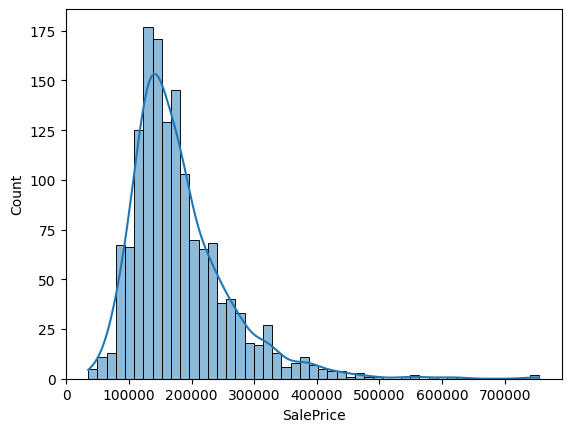

In [169]:
sns.histplot(df['SalePrice'], kde=True)
plt.show()

# Let's check the number of N/A entries by feature

In [170]:
na_counts = df.isna().sum()
na_fraction = df.isna().mean()
na_stats = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_fraction': df.isna().mean()
})
na_stats = na_stats.sort_values(by='missing_fraction', ascending=False)
na_stats['missing_percent'] = na_stats['missing_fraction'] * 100
na_stats[na_stats['missing_percent'] > 0]

,missing_count,missing_fraction,missing_percent
PoolQC,1453,0.995205,99.520548
MiscFeature,1406,0.963014,96.301370
Alley,1369,0.937671,93.767123
Fence,1179,0.807534,80.753425
MasVnrType,872,0.597260,59.726027
FireplaceQu,690,0.472603,47.260274
LotFrontage,259,0.177397,17.739726
GarageQual,81,0.055479,5.547945
GarageFinish,81,0.055479,5.547945
GarageType,81,0.055479,5.547945


# Seperate x from y # 

In [171]:
target_col = 'SalePrice'
X = df.drop(columns=[target_col])
y = df[target_col]

# Seperate numerical from categorical 

In [172]:
num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.select_dtypes(exclude=[np.number]).columns
X_num = X[num_cols]
X_cat = X[cat_cols]

# Let's check how the missing values are distributed 

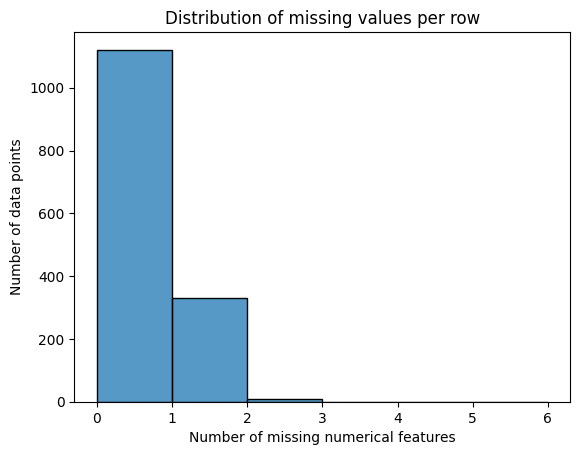

In [173]:
num_df = df.select_dtypes(include=[np.number])

missing_per_row = num_df.isna().sum(axis=1)

sns.histplot(missing_per_row, bins=range(missing_per_row.min(),missing_per_row.max()+5))

plt.xlabel("Number of missing numerical features")
plt.ylabel("Number of data points")
plt.title("Distribution of missing values per row")

plt.show()

In [174]:
missing_cols = (
    df.select_dtypes(include=[np.number])
      .isna()
      .sum()
)

missing_cols = missing_cols[missing_cols > 0]

print(missing_cols.sort_values(ascending=False))

LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
dtype: int64


# Sort the numerical features by their correlation with the price

In [175]:
df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

# Now sort them by mutual information

In [176]:
X_num_clean = X_num.fillna(X_num.median())
mi = mutual_info_regression(X_num_clean, y)
mi_series = pd.Series(mi, index=X_num_clean.columns)
mi_series = mi_series.sort_values(ascending=False)
mi_series

OverallQual      0.581569
GrLivArea        0.483138
GarageCars       0.375221
TotalBsmtSF      0.368823
YearBuilt        0.366626
GarageArea       0.363027
1stFlrSF         0.309282
GarageYrBlt      0.298738
MSSubClass       0.269892
FullBath         0.259730
YearRemodAdd     0.257884
LotFrontage      0.223695
TotRmsAbvGrd     0.218018
2ndFlrSF         0.184395
Fireplaces       0.162286
LotArea          0.158930
BsmtFinSF1       0.152254
OpenPorchSF      0.141929
OverallCond      0.120786
BsmtUnfSF        0.119709
WoodDeckSF       0.105032
MasVnrArea       0.083711
HalfBath         0.081452
KitchenAbvGr     0.054739
BedroomAbvGr     0.054441
EnclosedPorch    0.033244
BsmtFullBath     0.027860
ScreenPorch      0.018406
LowQualFinSF     0.013230
BsmtFinSF2       0.002570
PoolArea         0.001334
Id               0.000000
BsmtHalfBath     0.000000
3SsnPorch        0.000000
MiscVal          0.000000
MoSold           0.000000
YrSold           0.000000
dtype: float64

# Plot the most important features against average house prices

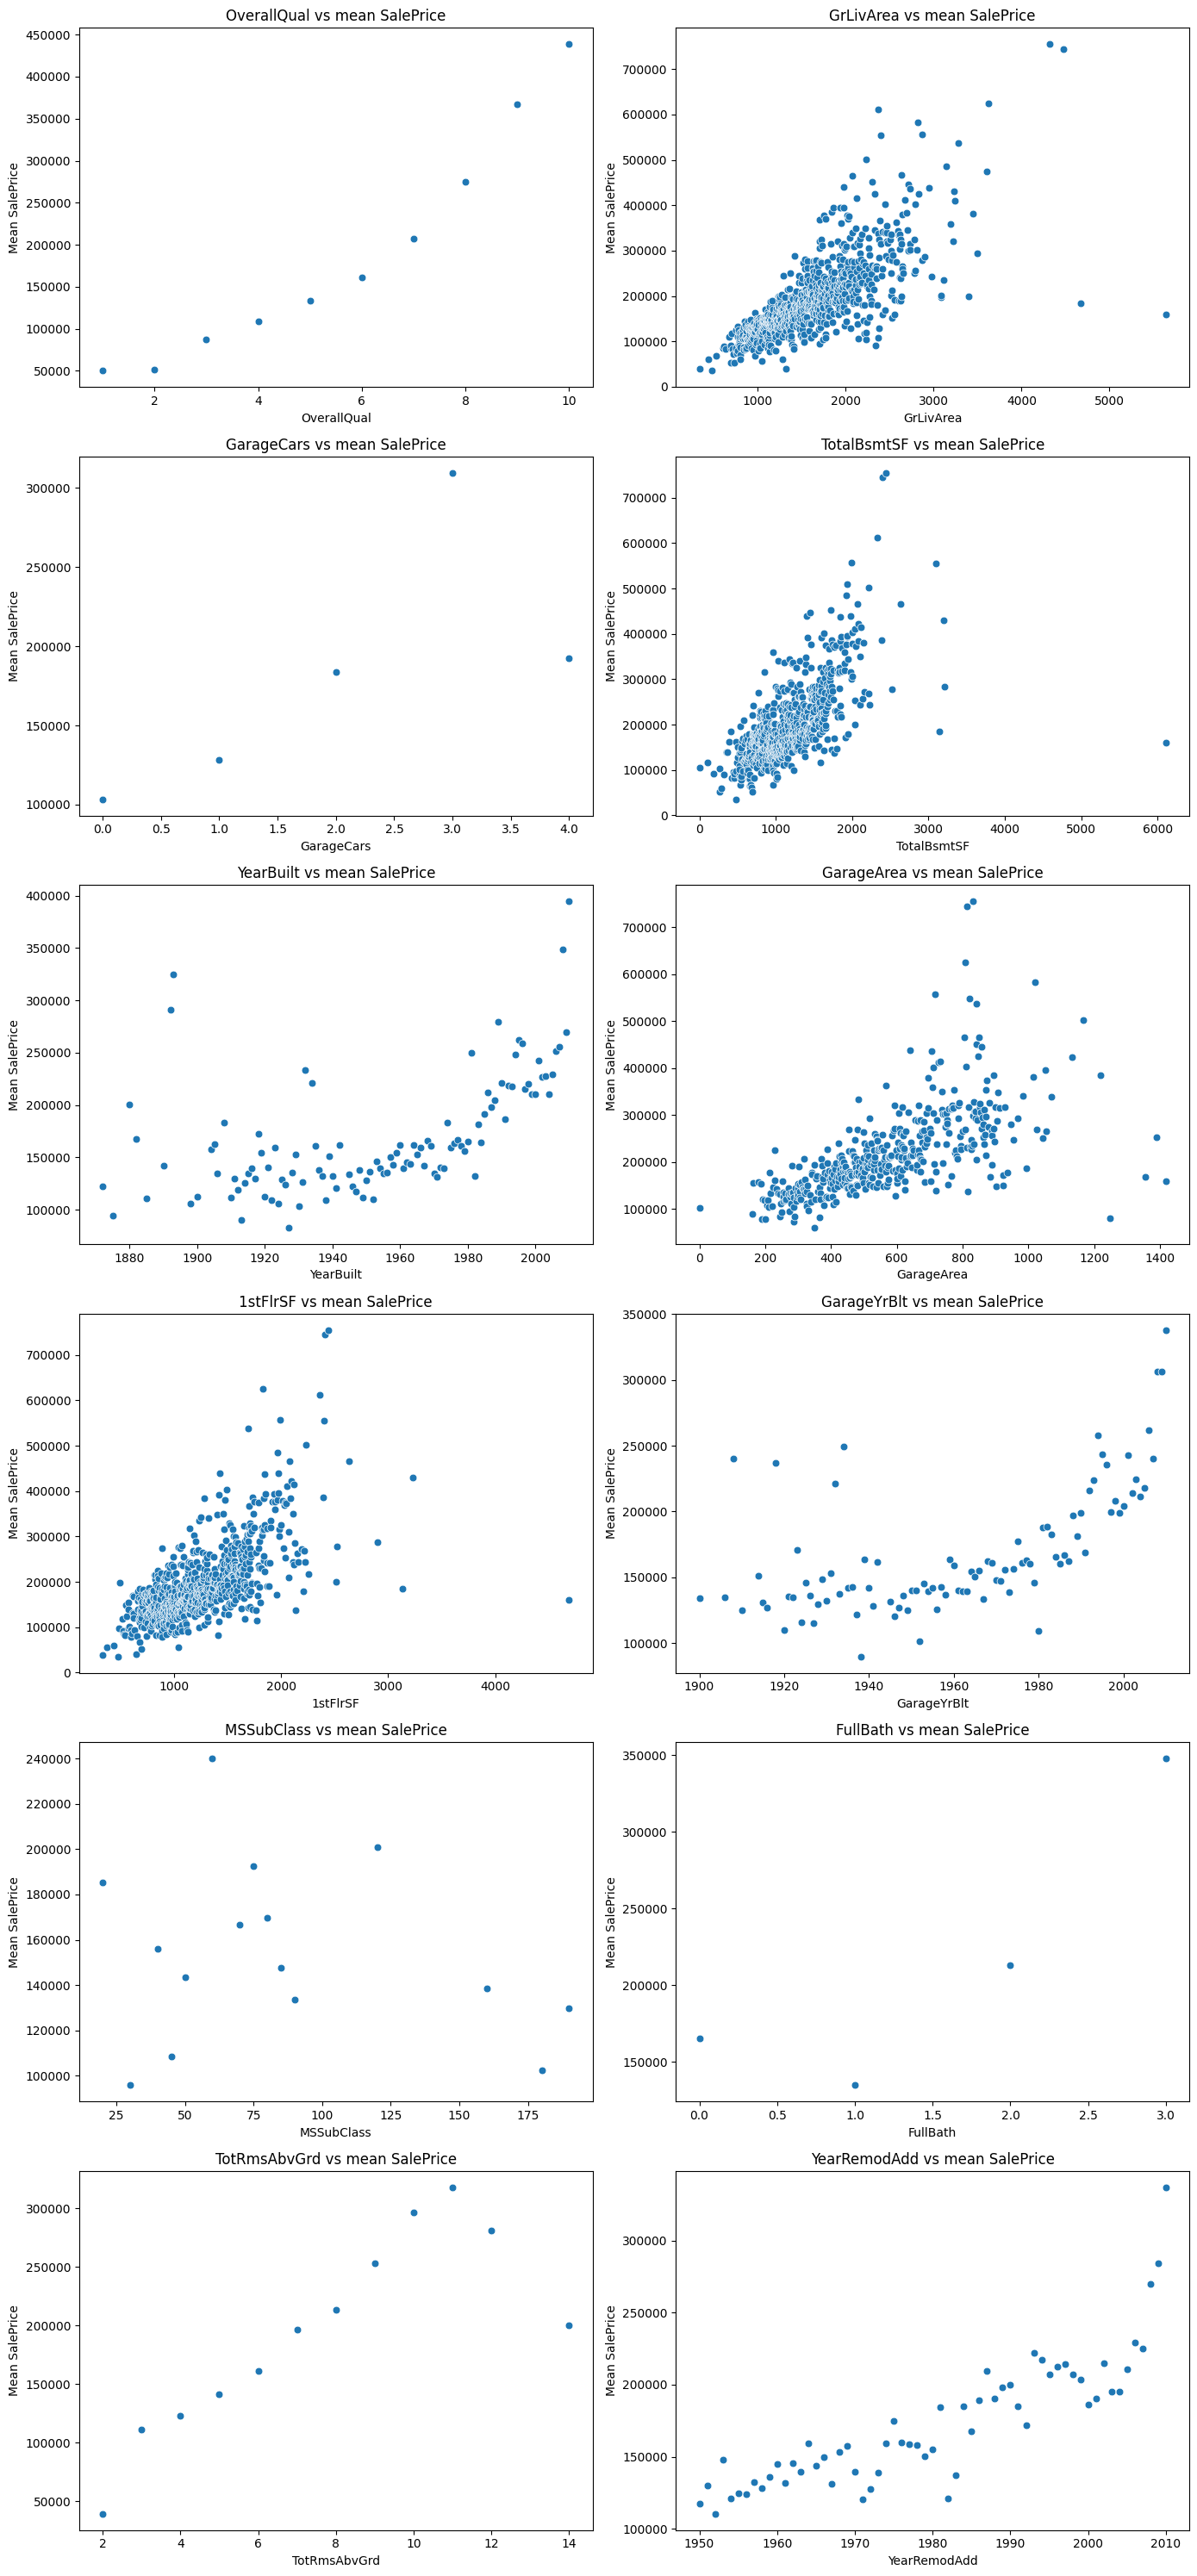

In [177]:
corr_series = X_num_clean.corrwith(y).abs().sort_values(ascending=False)
top_corr = corr_series.head(10).index

top_mi = mi_series.head(10).index

combined_features = list(top_mi) + [f for f in top_corr if f not in top_mi]


fig, axes = plt.subplots(
    nrows=(len(combined_features) + 1) // 2,
    ncols=2,
    figsize=(14, 5 * ((len(combined_features) + 1) // 2))
)

axes = axes.flatten()

for i, feature in enumerate(combined_features):
    
    df_plot = X_num_clean[[feature]].copy()
    df_plot["SalePrice"] = y.values


    df_agg = df_plot.groupby(feature, as_index=False)["SalePrice"].mean()

    sns.scatterplot(
        data=df_agg,
        x=feature,
        y="SalePrice",
        ax=axes[i],
        s=40  # point size
    )

    axes[i].set_title(f"{feature} vs mean SalePrice")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Mean SalePrice")

plt.tight_layout()
plt.show()



# Plot logarithms

OverallQual (Above Mean) Slope: 1.41
OverallQual (Below Mean) Slope: 0.77
GrLivArea (Above Mean) Slope: 0.66
GrLivArea (Below Mean) Slope: 0.62
GarageCars (Above Mean) Slope: 0.83
GarageCars (Below Mean) Slope: 0.58
TotalBsmtSF (Above Mean) Slope: 0.81
TotalBsmtSF (Below Mean) Slope: 0.40
YearBuilt (Above Mean) Slope: 0.72
YearBuilt (Below Mean) Slope: 0.37
GarageArea (Above Mean) Slope: 0.73
GarageArea (Below Mean) Slope: 0.48
1stFlrSF (Above Mean) Slope: 0.84
1stFlrSF (Below Mean) Slope: 0.07
GarageYrBlt (Above Mean) Slope: 0.47
GarageYrBlt (Below Mean) Slope: 0.17
MSSubClass (Above Mean) Slope: 0.19
MSSubClass (Below Mean) Slope: -0.99
FullBath (Above Mean) Slope: 0.86
FullBath (Below Mean) Slope: 0.25
TotRmsAbvGrd (Above Mean) Slope: 0.56
TotRmsAbvGrd (Below Mean) Slope: 0.42
YearRemodAdd (Above Mean) Slope: 0.58
YearRemodAdd (Below Mean) Slope: 0.40


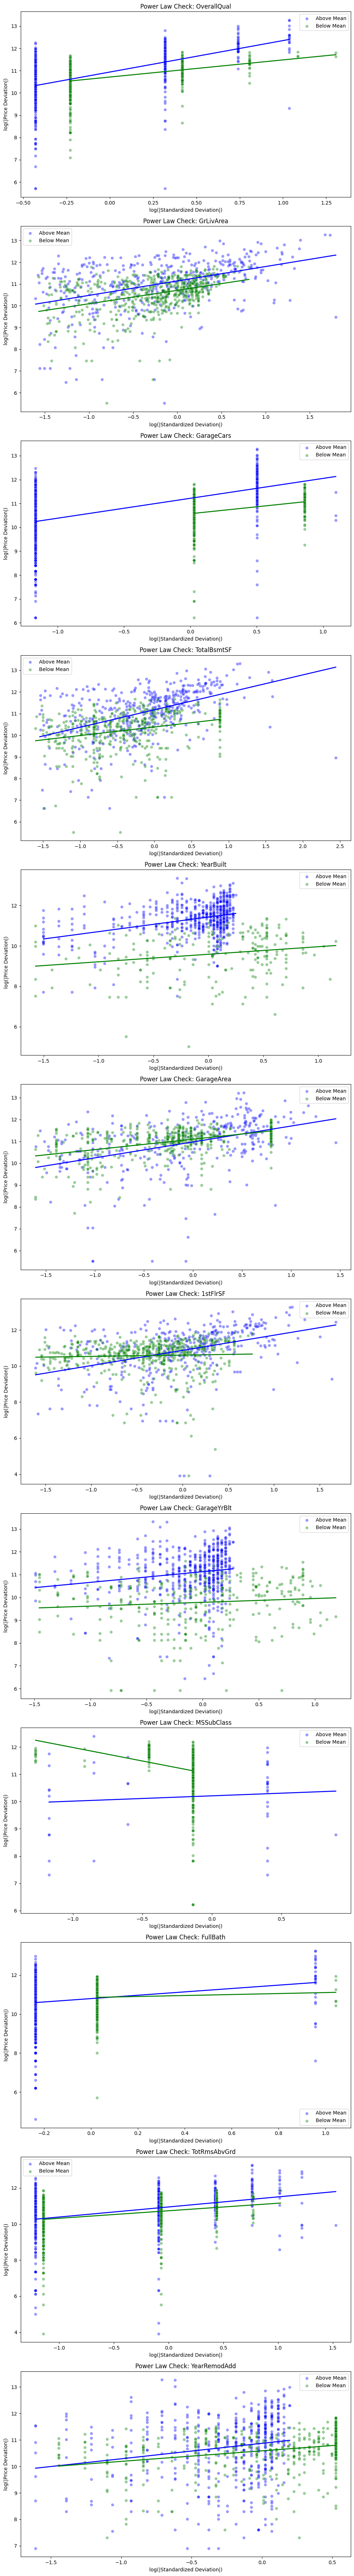

In [178]:

y_series = pd.Series(y.values.flatten()) if hasattr(y, 'values') else pd.Series(y)
scaler = StandardScaler()

fig, axes = plt.subplots(
    nrows=len(combined_features), 
    ncols=1, 
    figsize=(10, 6 * len(combined_features))
)

for i, feature in enumerate(combined_features):
    x_raw = X_num_clean[feature].values.reshape(-1, 1)
    x_scaled = np.asarray(scaler.fit_transform(x_raw)).ravel()
    
    distances = np.abs(x_scaled)
    closest_indices = np.argsort(distances)[:20]
    y_mu = y_series.iloc[closest_indices].median() 
    
    dx_orig = x_scaled 
    dy_orig = y_series.values - y_mu
    
    mask_pos = (dx_orig > 0.2) & (dy_orig > 0)
    mask_neg = (dx_orig < -0.2) & (dy_orig < 0)
    
    ax = axes[i] if len(combined_features) > 1 else axes
    
    for mask, label, color in zip([mask_pos, mask_neg], ["Above Mean", "Below Mean"], ["blue", "green"]):
        if mask.sum() > 5:
            log_dx = np.log(np.abs(dx_orig[mask])).reshape(-1, 1)
            log_dy = np.log(np.abs(dy_orig[mask]))
            
            model = LinearRegression().fit(log_dx, log_dy)
            slope = model.coef_[0]
            
            sns.scatterplot(x=log_dx.flatten(), y=log_dy, ax=ax, label=label, color=color, alpha=0.4)
            
            line_x = np.linspace(log_dx.min(), log_dx.max(), 50).reshape(-1, 1)
            ax.plot(line_x, model.predict(line_x), color=color, lw=2)
            print(f"{feature} ({label}) Slope: {slope:.2f}")

    ax.set_title(f"Power Law Check: {feature}")
    ax.set_xlabel("log(|Standardized Deviation|)")
    ax.set_ylabel("log(|Price Deviation|)")
    ax.legend()

plt.tight_layout()
plt.show()

# FeatureSelector

In [179]:
class FeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, top_n=10):
        self.top_n = top_n

    def fit(self, X, y):
        mi = mutual_info_regression(X, y)
        mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
        corr_series = X.corrwith(y).abs().sort_values(ascending=False)
        top_mi = mi_series.head(self.top_n).index
        top_corr = corr_series.head(self.top_n).index
        self.selected_features_ = list(top_mi) + [f for f in top_corr if f not in top_mi]
        return self

    def transform(self, X):
        return X[self.selected_features_]

# PolynomialExpander

In [180]:
class PolynomialExpander(BaseEstimator, TransformerMixin):
    def __init__(self, degrees=[2, 3]):
        self.degrees = degrees

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        for col in X.columns:
            for d in self.degrees:
                X_out[f"{col}_pow{d}"] = X[col] ** d
        return X_out

# pipeline

In [181]:
pipeline = Pipeline([
    ('imputer', SimpleImputer()),
    ('selector', FeatureSelector(top_n=10)),
    ('expander', PolynomialExpander()),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

param_grid = {
    'imputer__strategy': ['mean', 'median', 'most_frequent'],
    'selector__top_n': [10, 15],
}

# Linear regression

In [182]:
grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_search.fit(X_num, y)

# ---- results ----
print("Best params:", grid_search.best_params_)

best_rmse = np.sqrt(-grid_search.best_score_)
print("Best RMSE:", best_rmse)


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# best model
best_model = grid_search.best_estimator_

# predictions on full data
y_pred = best_model.predict(X_num)

# ---- basic metrics ----
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("\n=== Metrics on full data ===")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

# ---- CV train vs validation comparison ----
results = grid_search.cv_results_
best_idx = grid_search.best_index_

train_rmse = np.sqrt(-results['mean_train_score'][best_idx])
val_rmse   = np.sqrt(-results['mean_test_score'][best_idx])

print("\n=== Train vs Validation ===")
print("Train RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)
print("Gap (overfitting indicator):", val_rmse - train_rmse)

# ---- std deviation (stability) ----
std_val = np.sqrt(results['std_test_score'][best_idx])

print("\n=== CV Stability ===")
print("Validation RMSE std:", std_val)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'imputer__strategy': 'most_frequent', 'selector__top_n': 10}
Best RMSE: 36202.238039761796

=== Metrics on full data ===
RMSE: 29699.977604241943
MAE: 19727.36619400195
R2: 0.860136635665643

=== Train vs Validation ===
Train RMSE: 29266.98207487034
Validation RMSE: 36202.238039761796
Gap (overfitting indicator): 6935.255964891458

=== CV Stability ===
Validation RMSE std: 25780.448270054956


 # Log the first model to mlflow

In [183]:
import mlflow
import dagshub
from kaggle_secrets import UserSecretsClient

# load secrets
secrets = UserSecretsClient()
username = secrets.get_secret("DAGSHUB_USERNAME")
token = secrets.get_secret("DAGSHUB_TOKEN")

# connect to DagsHub
dagshub.init(repo_owner=username, repo_name="house-prices", mlflow=True)


mlflow.set_experiment("house-prices-experiment")


with mlflow.start_run(run_name="linear_regression_poly"):

    # --- log best hyperparams ---
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_param("top_n_features", grid_search.best_estimator_['selector'].top_n)
    mlflow.log_param("poly_degrees", "2, 3")
    mlflow.log_param("model_type", "LinearRegression")

    # --- log CV metrics ---
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("overfit_gap", val_rmse - train_rmse)



    # --- log the model ---
    mlflow.sklearn.log_model(best_model, artifact_path="model")


Initialized MLflow to track repo "grtsir22/house-prices"

Repository grtsir22/house-prices initialized!

2026/04/13 17:30:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 17:31:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run linear_regression_poly at: https://dagshub.com/grtsir22/house-prices.mlflow/#/experiments/0/runs/c7408832d15741e682c21ff09b89d33d
🧪 View experiment at: https://dagshub.com/grtsir22/house-prices.mlflow/#/experiments/0


# Linear regression with outliers removed

In [184]:
# --- split first ---
X_num_train, X_num_val, y_train, y_val = train_test_split(
    X_num, y, test_size=0.2, random_state=42
)

# --- outlier removal on training set only ---
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (y_train >= Q1 - 1.5 * IQR) & (y_train <= Q3 + 1.5 * IQR)
X_num_train_clean = X_num_train[outlier_mask]
y_train_clean = y_train[outlier_mask]
print(f"Removed {(~outlier_mask).sum()} outliers out of {len(y_train)} training samples")

# --- pipeline ---
pipeline = Pipeline([
    ('imputer', SimpleImputer()),
    ('selector', FeatureSelector(top_n=10)),
    ('expander', PolynomialExpander(degrees=[2])),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

param_grid = {
    'imputer__strategy': ['mean', 'median', 'most_frequent'],
    'selector__top_n': [10, 15],
}

grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_search.fit(X_num_train_clean, y_train_clean)

# --- results ---
print("Best params:", grid_search.best_params_)
best_rmse = np.sqrt(-grid_search.best_score_)
print("Best CV RMSE:", best_rmse)

best_model = grid_search.best_estimator_

# --- metrics on validation set (untouched, includes outliers) ---
y_pred_val = best_model.predict(X_num_val)
y_pred_train = best_model.predict(X_num_train_clean)

rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae_val = mean_absolute_error(y_val, y_pred_val)
r2_val = r2_score(y_val, y_pred_val)

rmse_train = np.sqrt(mean_squared_error(y_train_clean, y_pred_train))

print("\n=== Validation Metrics (unseen, with outliers) ===")
print("RMSE:", rmse_val)
print("MAE:", mae_val)
print("R2:", r2_val)

# --- CV train vs validation ---
results = grid_search.cv_results_
best_idx = grid_search.best_index_
cv_train_rmse = np.sqrt(-results['mean_train_score'][best_idx])
cv_val_rmse   = np.sqrt(-results['mean_test_score'][best_idx])
std_val       = np.sqrt(results['std_test_score'][best_idx])

print("\n=== Train vs Validation ===")
print("CV Train RMSE:", cv_train_rmse)
print("CV Val RMSE:", cv_val_rmse)
print("Gap (overfitting indicator):", cv_val_rmse - cv_train_rmse)
print("CV Val RMSE std:", std_val)


Removed 48 outliers out of 1168 training samples
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'imputer__strategy': 'mean', 'selector__top_n': 15}
Best CV RMSE: 23511.391788619356

=== Validation Metrics (unseen, with outliers) ===
RMSE: 39830.94981942757
MAE: 21545.906821023356
R2: 0.7931633517709851

=== Train vs Validation ===
CV Train RMSE: 21320.50847295626
CV Val RMSE: 23511.391788619356
Gap (overfitting indicator): 2190.883315663097
CV Val RMSE std: 10836.675988049237


# mlflow second experiment 

In [185]:

with mlflow.start_run(run_name="linear_regression_no_outliers"):

    mlflow.log_params(grid_search.best_params_)
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("poly_degrees", "2")
    mlflow.log_param("outlier_removal", "IQR_1.5_train_only") 

    mlflow.log_metric("n_outliers_removed", int((~outlier_mask).sum()))
    mlflow.log_metric("n_train_samples", int(outlier_mask.sum()))
    mlflow.log_metric("n_val_samples", len(y_val))

    mlflow.log_metric("cleaned_val_rmse", cv_val_rmse)
    mlflow.log_metric("cleaned_train_rmse", cv_train_rmse)
    

    mlflow.log_metric("val_rmse", rmse_val)
    mlflow.log_metric("val_mae", mae_val)
    mlflow.log_metric("val_r2", r2_val)
    mlflow.log_metric("train_rmse", rmse_train)
    mlflow.log_metric("overfit_gap", rmse_val - rmse_train)

    mlflow.sklearn.log_model(best_model, artifact_path="model")


2026/04/13 17:31:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 17:31:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run linear_regression_no_outliers at: https://dagshub.com/grtsir22/house-prices.mlflow/#/experiments/0/runs/8f2f19d1d09742d8a6a35ed7e578154b
🧪 View experiment at: https://dagshub.com/grtsir22/house-prices.mlflow/#/experiments/0


# Let's incorporate the categorical variables now

# Check all possible values for each categorical feature

In [186]:
for col in cat_cols:
    unique_vals = df[col].unique()
    print(f"{col}:")
    print(f"  #unique = {len(unique_vals)}")
    print(f"  values = {unique_vals}")
    print() 


MSZoning:
  #unique = 5
  values = ['RL' 'RM' 'C (all)' 'FV' 'RH']

Street:
  #unique = 2
  values = ['Pave' 'Grvl']

Alley:
  #unique = 3
  values = [nan 'Grvl' 'Pave']

LotShape:
  #unique = 4
  values = ['Reg' 'IR1' 'IR2' 'IR3']

LandContour:
  #unique = 4
  values = ['Lvl' 'Bnk' 'Low' 'HLS']

Utilities:
  #unique = 2
  values = ['AllPub' 'NoSeWa']

LotConfig:
  #unique = 5
  values = ['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']

LandSlope:
  #unique = 3
  values = ['Gtl' 'Mod' 'Sev']

Neighborhood:
  #unique = 25
  values = ['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel' 'Somerst' 'NWAmes'
 'OldTown' 'BrkSide' 'Sawyer' 'NridgHt' 'NAmes' 'SawyerW' 'IDOTRR'
 'MeadowV' 'Edwards' 'Timber' 'Gilbert' 'StoneBr' 'ClearCr' 'NPkVill'
 'Blmngtn' 'BrDale' 'SWISU' 'Blueste']

Condition1:
  #unique = 9
  values = ['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe' 'RRNn' 'RRAn' 'PosA' 'RRNe']

Condition2:
  #unique = 8
  values = ['Norm' 'Artery' 'RRNn' 'Feedr' 'PosN' 'PosA' 'RRAn' 'RRAe']

BldgType:
  #uniq

# Plot errors

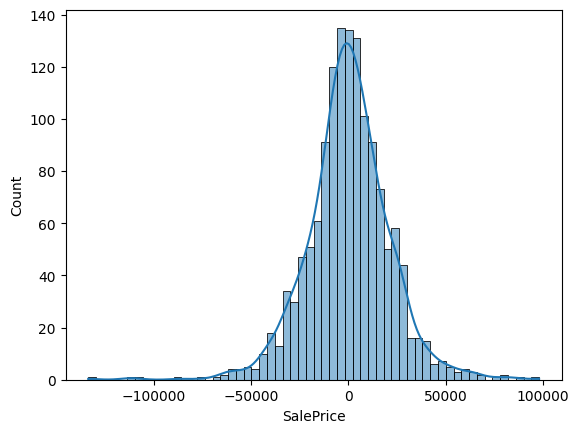

In [187]:
y_pred = best_model.predict(X_num_filtered)
y_offsets = y_filtered - y_pred
sns.histplot(y_offsets, kde=True)
plt.show()

# Target encoding and linear regression 

# SmoothTargetEncoder

In [188]:
class SmoothTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, alpha=10):
        self.alpha = alpha
    def fit(self, X, y):
        X = pd.DataFrame(X)
        y = pd.Series(y)
        self.global_mean_ = y.mean()
        self.stats_ = {}
        for col in X.columns:
            col_data = X[col]
            stats = pd.DataFrame({
                'mean': y.groupby(col_data).mean(),
                'count': col_data.value_counts()
            }) 
            stats['smoothed'] = (
                (stats['mean'] * stats['count'] + self.global_mean_ * self.alpha) /
                (stats['count'] + self.alpha)
            )
            self.stats_[col] = stats['smoothed']
        return self
    def transform(self, X):
        X = pd.DataFrame(X)
        encoded = pd.DataFrame(index=X.index)
        for col in X.columns:
            encoded[col] = X[col].map(self.stats_[col]).astype(float)
        col_medians = encoded.median().fillna(self.global_mean_)
        encoded = encoded.fillna(col_medians)
        return encoded

# ResidualStackedRegressor

In [189]:
class ResidualStackedRegressor(BaseEstimator):
    def __init__(self, num_pipeline, cat_pipeline):
        self.num_pipeline = num_pipeline
        self.cat_pipeline = cat_pipeline

    def fit(self, X, y):
        X_num = X.select_dtypes(include=[np.number])
        X_cat = X.select_dtypes(exclude=[np.number])
        self.num_pipeline.fit(X_num, y)

        # compute residuals on full data for categorical pipeline
        y_pred_num = self.num_pipeline.predict(X_num)
        y_offsets = y - y_pred_num
        self.cat_pipeline.fit(X_cat, y_offsets)

        return self

    def predict(self, X):
        X_num = X.select_dtypes(include=[np.number])
        X_cat = X.select_dtypes(exclude=[np.number])
        return self.num_pipeline.predict(X_num) + self.cat_pipeline.predict(X_cat)


#  pipelines

In [190]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer()),
    ('selector', FeatureSelector(top_n=15)),
    ('expander', PolynomialExpander(degrees=[2,3])),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

cat_pipeline = Pipeline([
    ('encoder', SmoothTargetEncoder()),
    ('feature_selector', RFE(estimator=LinearRegression())),
    ('model', LinearRegression())
])

stacked_model = ResidualStackedRegressor(
    num_pipeline=num_pipeline,
    cat_pipeline=cat_pipeline
)

# fitting

In [191]:

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
stacked_model.fit(X_train, y_train)
y_pred = stacked_model.predict(X_val)

val_rmse = np.sqrt(mean_squared_error(y_val, y_pred))
val_mae = mean_absolute_error(y_val, y_pred)
val_r2 = r2_score(y_val, y_pred)

print("Validation RMSE:", val_rmse)
print("Validation MAE:", val_mae)
print("Validation R2:", val_r2)



Validation RMSE: 30542.340301477663
Validation MAE: 20135.167407653527
Validation R2: 0.8783839792605956


# mlflow

In [192]:
# plug in best params from your earlier grid searches
stacked_model.num_pipeline.set_params(
    imputer__strategy='median',   # replace with grid_search.best_params_ from run 2
    selector__top_n=10
)
stacked_model.cat_pipeline.set_params(
    encoder__alpha=10,            # replace with grid_search.best_params_ from run 3
    feature_selector__n_features_to_select=15
)

# stacked_model.fit(X, y)
y_pred = stacked_model.predict(X_train)

rmse = np.sqrt(mean_squared_error(y_train, y_pred))
mae = mean_absolute_error(y_train, y_pred)
r2 = r2_score(y_train, y_pred)

with mlflow.start_run(run_name="stacked_num_cat_residual"):

    # num pipeline params
    mlflow.log_param("num__imputer_strategy", stacked_model.num_pipeline['imputer'].strategy)
    mlflow.log_param("num__top_n_features", stacked_model.num_pipeline['selector'].top_n)
    mlflow.log_param("num__poly_degrees", "2, 3")
    mlflow.log_param("num__model", "LinearRegression")

    # cat pipeline params
    mlflow.log_param("cat__alpha", stacked_model.cat_pipeline['encoder'].alpha)
    mlflow.log_param("cat__n_features_rfe", stacked_model.cat_pipeline['feature_selector'].n_features_to_select)
    mlflow.log_param("cat__model", "LinearRegression")


    # metrics
    mlflow.log_metric("train_rmse", rmse)

    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("val_mae", val_mae)
    mlflow.log_metric("val_r2", val_r2)
    mlflow.log_metric("overfit_gap", val_rmse - rmse)

    mlflow.sklearn.log_model(stacked_model, artifact_path="model")

2026/04/13 17:32:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 17:32:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run stacked_num_cat_residual at: https://dagshub.com/grtsir22/house-prices.mlflow/#/experiments/0/runs/74615c537ed34a9ab70c6e32bea43bb1
🧪 View experiment at: https://dagshub.com/grtsir22/house-prices.mlflow/#/experiments/0
[CV] END .........imputer__strategy=mean, selector__top_n=10; total time=   0.5s
[CV] END .........imputer__strategy=mean, selector__top_n=10; total time=   0.5s
[CV] END .........imputer__strategy=mean, selector__top_n=15; total time=   0.6s
[CV] END .......imputer__strategy=median, selector__top_n=10; total time=   0.5s
[CV] END .......imputer__strategy=median, selector__top_n=15; total time=   0.6s
[CV] END imputer__strategy=most_frequent, selector__top_n=10; total time=   0.6s
[CV] END imputer__strategy=most_frequent, selector__top_n=15; total time=   0.6s
[CV] END .........imputer__strategy=mean, selector__top_n=10; total time=   0.4s
[CV] END .........imputer__strategy=mean, selector__top_n=10; total time=   0.4s
[CV] END .........imputer__strategy=mean,